# Đánh giá Không gian tiềm ẩn (Latent Evaluation)
Sử dụng Notebook này để trực quan hoá khả năng phân tách danh tính của $z$ (t-SNE), tính toán độ chính xác truy xuất (Rank-1 Retrieval) và nội suy (Latent Walk).

In [ ]:
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
from sklearn.manifold import TSNE
import torch.nn.functional as F

# Thêm đường dẫn thư mục gốc
sys.path.append(os.path.dirname(os.getcwd()))
from src.datasets.data_module import PalmDataModule
from src.engine.lightning_module import GenerativeLightningModule

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 1. Cấu hình và Tải Mô hình

In [ ]:
# THAY ĐỔI ĐƯỜNG DẪN CHECKPOINT CỦA BẠN VÀO ĐÂY
VERSION_DIR = "E:/palm/logs/version_2"
CHECKPOINT_PATH = os.path.join(VERSION_DIR, "checkpoints/best.ckpt")
CONFIG_PATH = os.path.join(VERSION_DIR, "config_backup.yaml")

# Load config
config = OmegaConf.load(CONFIG_PATH)
config_dict = OmegaConf.to_container(config, resolve=True)

# Khởi tạo DataLoader
datamodule = PalmDataModule(config_dict)
datamodule.setup(stage="fit")
val_loader = datamodule.val_dataloader()

# Khởi tạo và nạp trọng số mô hình
model = GenerativeLightningModule(config_dict)
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint["state_dict"], strict=False)
model.to(device)
model.eval()
print("Model loaded successfully!")

Loaded TongjiDataset (mixed mode) - Train: 9600 samples.
Loaded TongjiDataset (mixed mode) - Val: 2400 samples.
--------------------------------------------------
[DATASET INFO] Tên Dataset: tongji
[DATASET INFO] Thư mục: E:/palm/data/Tongji
[DATASET INFO] Split Mode: Mixed
[DATASET INFO] Tập Train: 9600 samples
[DATASET INFO] Tập Val: 2400 samples
--------------------------------------------------
🚀 Sử dụng hàm mất mát đẩy/kéo (Metric Learning): MultiSimilarityLoss 🚀
Model loaded successfully!


## 2. Trích xuất đặc trưng ($z$)

In [27]:
all_z = []
all_labels = []

with torch.no_grad():
    for i, (images, labels) in enumerate(val_loader):
        images = images.to(device)
        # Bắt buộc mode="reconstruct" (hoặc truyền qua encoder) để lấy mu
        outputs = model(images, decode=False)
        mu = outputs["mu"]
    
        # Ta dùng proj nếu Contrastive áp dụng lên proj, hoặc dùng mu trực tiếp.
        # Ở đây ta đánh giá không gian tiềm ẩn cốt lõi mu
        all_z.append(mu.cpu())
        all_labels.append(labels)
        
        # Lấy khoảng vài chục batch để TSNE đỡ nặng
        if i > 20: break

all_z = torch.cat(all_z, dim=0)
all_labels = torch.cat(all_labels, dim=0)
print(f"Extracted {all_z.shape[0]} latent vectors of dimension {all_z.shape[1]}.")

Extracted 1408 latent vectors of dimension 64.


In [18]:
print(all_labels)

tensor([  0,   0,   0,  ..., 351, 351, 351])


## 3. Trực quan hoá bằng t-SNE

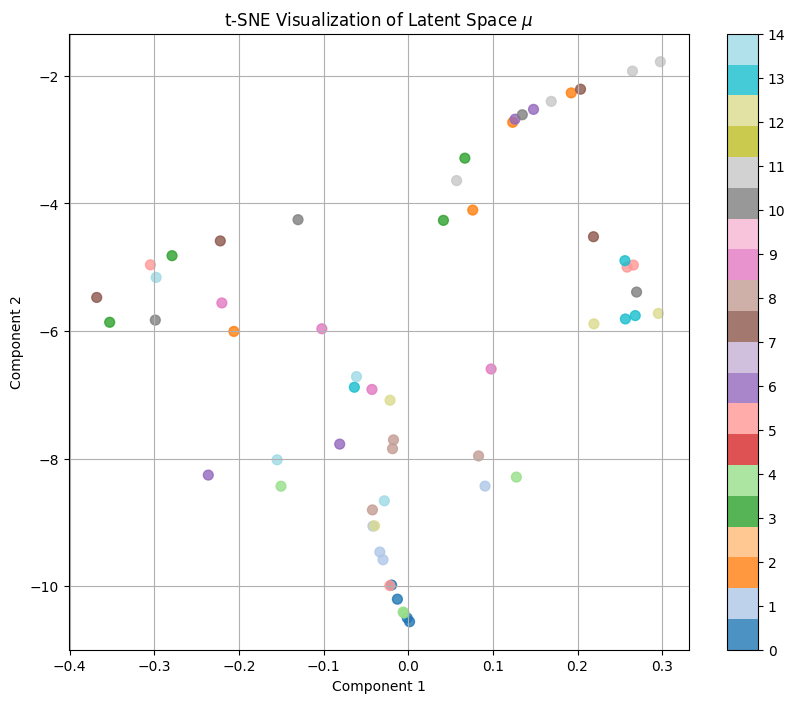

In [28]:
# Chỉ lấy khoảng 10-15 người (Classes) để màu sắc trên biểu đồ dễ phân biệt
unique_labels = torch.unique(all_labels)[:15]
mask = torch.isin(all_labels, unique_labels)

z_subset = all_z[mask].numpy()
labels_subset = all_labels[mask].numpy()

# Chạy t-SNE
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
z_2d = tsne.fit_transform(z_subset)

# Vẽ biểu đồ
plt.figure(figsize=(10, 8))
scatter = plt.scatter(z_2d[:, 0], z_2d[:, 1], c=labels_subset, cmap="tab20", s=50, alpha=0.8)
plt.colorbar(scatter, ticks=np.unique(labels_subset))
plt.title("t-SNE Visualization of Latent Space $\mu$")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(True)
plt.show()

## 4. Đánh giá Khả năng Truy xuất (Rank-1 Accuracy)

In [24]:
# Chuẩn hóa L2 các vector để dùng Cosine Similarity
z_norm = F.normalize(all_z, p=2, dim=1)

# Tính ma trận độ tương đồng Cosine Similarity giữa MỌI vector với nhau
sim_matrix = torch.matmul(z_norm, z_norm.T)

# Loại bỏ đường chéo (không so sánh với chính nó)
sim_matrix.fill_diagonal_(-1.0)

# Tìm vị trí (index) của vector có độ tương đồng lớn nhất
best_match_indices = torch.argmax(sim_matrix, dim=1)

# Lấy nhãn của vector giống nhất đó
predicted_labels = all_labels[best_match_indices]

# Tính độ chính xác
correct = (predicted_labels == all_labels).sum().item()
rank1_acc = correct / len(all_labels)

print(f"Tổng số mẫu kiểm tra: {len(all_labels)}")
print(f"Số mẫu truy xuất đúng ID: {correct}")
print(f"Độ chính xác Rank-1: {rank1_acc * 100:.2f}%")

Tổng số mẫu kiểm tra: 1408
Số mẫu truy xuất đúng ID: 47
Độ chính xác Rank-1: 3.34%


## 5. Nội suy không gian (Latent Walk)
Kéo từ từ vector $z_1$ sang $z_2$ để xem hình ảnh thay đổi như thế nào.

In [25]:
import torchvision.utils as vutils

num_steps = 10

# Chọn 2 ảnh bất kỳ từ loader
imgs, lbls = next(iter(val_loader))
img1, img2 = imgs[0:1].to(device), imgs[1:2].to(device)

with torch.no_grad():
    z1 = model(img1, decode=False)["mu"]
    z2 = model(img2, decode=False)["mu"]
    
    interpolated_imgs = []
    for alpha in np.linspace(0, 1, num_steps):
        z_interp = (1 - alpha) * z1 + alpha * z2
        
        # Đối với UNet, việc decode trực tiếp z gặp khó vì thiếu skip connection từ encoder
        # Ta dùng hàm generate_unconditional mô phỏng.
        if hasattr(model.model, "use_decoder"):
            if hasattr(model.model, "fc_dec"):
                out = model.model.fc_dec(z_interp)
                out = out.view(-1, 512, model.model.bottleneck_size, model.model.bottleneck_size)
                out = model.model.up1(out, torch.zeros_like(model.model.down2(model.model.down1(model.model.inc(img1)))))
            pass
            
        print(f"Alpha {alpha:.2f}: Distance to z1: {torch.norm(z_interp - z1):.2f}")
        
print("Ghi chú: Đối với kiến trúc UNet, nội suy ảnh rất khó vì nó lệ thuộc mạnh vào các Skip Connections từ ảnh ban đầu (x1, x2, x3). Sự thay đổi của z chỉ đóng vai trò FiLM điều chế (modulation), do đó ảnh lai giữa hai vân tay sẽ vẫn giữ nguyên cấu trúc ảnh gốc truyền vào. Để nội suy hoàn toàn, bạn cần một bộ Decoder thuần tuý (như ProbabilisticPalmModel) không dùng đường tắt.")

Alpha 0.00: Distance to z1: 0.00
Alpha 0.11: Distance to z1: 0.01
Alpha 0.22: Distance to z1: 0.01
Alpha 0.33: Distance to z1: 0.02
Alpha 0.44: Distance to z1: 0.02
Alpha 0.56: Distance to z1: 0.03
Alpha 0.67: Distance to z1: 0.03
Alpha 0.78: Distance to z1: 0.04
Alpha 0.89: Distance to z1: 0.05
Alpha 1.00: Distance to z1: 0.05
Ghi chú: Đối với kiến trúc UNet, nội suy ảnh rất khó vì nó lệ thuộc mạnh vào các Skip Connections từ ảnh ban đầu (x1, x2, x3). Sự thay đổi của z chỉ đóng vai trò FiLM điều chế (modulation), do đó ảnh lai giữa hai vân tay sẽ vẫn giữ nguyên cấu trúc ảnh gốc truyền vào. Để nội suy hoàn toàn, bạn cần một bộ Decoder thuần tuý (như ProbabilisticPalmModel) không dùng đường tắt.
